In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import pickle
import os
import glob

import pingouin as pg
from statsmodels.stats.multicomp import pairwise_tukeyhsd

import statsmodels.api as sm
from statsmodels.formula.api import ols
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'


/home/ladako/anaconda3/envs/py396/lib/python3.9/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.5.5.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [ ]:
# set up directories
basedir = '/home/ladako/nas1/projects/pacman'
datdir = os.path.join(basedir, 'path', 'to', 'results')
savedir = '/dir/to/save/figure'

files = glob.glob(os.path.join(datdir, '*.pickle'))


In [ ]:
# load all files and concatenate them into a single dataframe
for i, file in enumerate(files):
    #print(i)
    if i==0:
        with open(file, 'rb') as f:
            df_all = pickle.load(f)
    else:
        with open(file, 'rb') as f:
            df_temp = pickle.load(f)
        df_all = pd.concat([df_all, df_temp], ignore_index=True)


In [ ]:
# calculate effective margin
df_all['Eff_margin'] = df_all['Radius']*np.sqrt(df_all['Dimensions'])

In [ ]:
# calculate mean and std for each subject, roi, and condition
df_all_mean = df_all.groupby(['Subject', 'ROI', 'Condition']).mean().reset_index()
df_all_std = df_all.groupby(['Subject', 'ROI', 'Condition']).std().reset_index()

df_all_long = pd.melt(df_all_mean, id_vars = ['Subject','ROI', 'Condition'], 
                      value_vars=['Capacity', 'Radius', 'Dimensions', 'Eff_margin'], 
                      var_name='ManifoldGeomMeasure', 
                      value_name='Value', 
                      ignore_index=False)
df_all_long = df_all_long.reset_index()


,index,Subject,ROI,Condition,ManifoldGeomMeasure,Value
0,0,pacman09,LO,HighHeat,Capacity,0.170156
1,1,pacman09,LO,LowHeat,Capacity,0.174253
2,2,pacman09,LO,Warmth,Capacity,0.174843
3,3,pacman09,V1,HighHeat,Capacity,0.165534
4,4,pacman09,V1,LowHeat,Capacity,0.167762
...,...,...,...,...,...,...
1771,439,pacman62,V2,LowHeat,Eff_margin,2.931635
1772,440,pacman62,V2,Warmth,Eff_margin,2.995375
1773,441,pacman62,hV4,HighHeat,Eff_margin,3.082971
1774,442,pacman62,hV4,LowHeat,Eff_margin,3.129170


Text(37.04390914351852, 0.5, '$\\alpha_M$')

Text(0.5, 1.0, 'Capacity')

Text(362.64986906828705, 0.5, '$R_M$')

Text(0.5, 1.0, 'Radius')

Text(688.5058289930555, 0.5, '$D_M$')

Text(0.5, 1.0, 'Dimensions')

Text(996.6117889178239, 0.5, 'a.u.')

Text(0.5, 1.0, 'Effective margin')

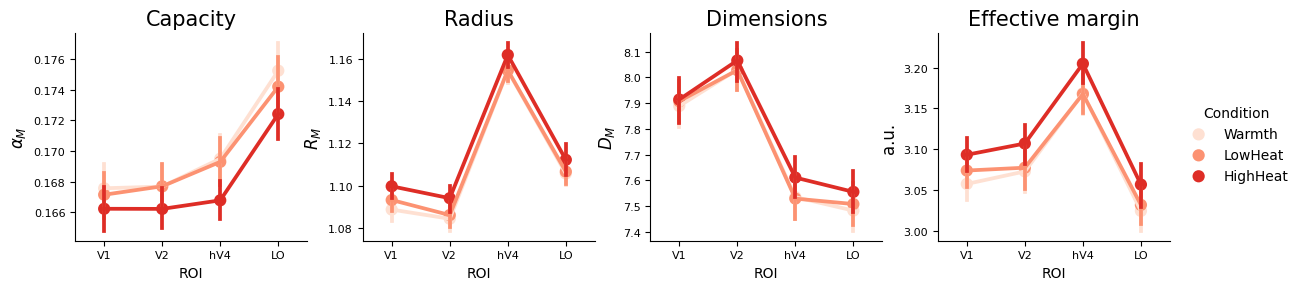

In [ ]:
# visualize the results using seaborn
save_figure = 0
cols = ["#fee0d2", "#fc9272", "#de2d26"]
rois = ['V1', 'V2', 'hV4', 'LO']
conditions = ['Warmth','LowHeat','HighHeat']

g = sns.FacetGrid(df_all_long, col='ManifoldGeomMeasure', sharey = False, hue= 'Condition', hue_order = conditions, palette=cols)
g.map(sns.pointplot, 'ROI', 'Value',order=rois) # errorbar defalut: CI 95% 
g.add_legend()


ManifoldGeomMeasure = ['Capacity', 'Radius', 'Dimensions', 'Effective margin'] 
ax_labels = [r'$\alpha_M$', r'$R_M$', r'$D_M$', 'a.u.'] 



for r in range(len(ax_labels)):
    g.axes[0][r].set_ylabel(f'{ax_labels[r]}', fontsize=12)
    g.axes[0][r].tick_params(labelsize=8)
    g.axes[0][r].set_title(f'{ManifoldGeomMeasure[r]}', fontsize=15)
    

if save_figure:
    plt.savefig(os.path.join(savedir, f'pain-induced-manifold-changes_manifold_geom_results.pdf'), bbox_inches='tight')
plt.show()

In [ ]:
# stats

rois = ['V1', 'V2', 'hV4', 'LO']
measure = ['Capacity', 'Radius', 'Dimensions' 'Eff_margin'] 
type_anova='post' #2,'post'

for var in measure:
    if type_anova == 2:
        # two-way anova
          
        model = ols(f'{var} ~ C(ROI) + C(Condition)+ C(ROI):C(Condition)', df_all_mean).fit() 
        aov_table = sm.stats.anova_lm(model, typ=2)
        print(f'{var}')
        aov_table['mean_sq'] = aov_table['sum_sq'] / aov_table['df']
        SS_total = aov_table['sum_sq'].sum() + model.ssr
        total_row = pd.DataFrame({
        'sum_sq': [SS_total],
        'df': [aov_table['df'].sum() + model.df_resid],
        'mean_sq': [None],
        'F': [None],
        'PR(>F)': [None]
        }, index=['Total'])

        # Append the total row to the ANOVA table
        anova_complete = pd.concat([aov_table, total_row])
        #print(f'{var}')
        anova_complete 
        
    
    if type_anova == 'post':
      
            
        print(f'{var} | ROI')
        tukey_roi = pairwise_tukeyhsd(df_all_mean[f'{var}'], df_all_mean['ROI'])
        print(tukey_roi)
        print('Exact p-values')
        print(tukey_roi.pvalues)
        
        print(f'{var} | Condition')
        tukey_cond = pairwise_tukeyhsd(df_all_mean[f'{var}'], df_all_mean['Condition'])
        print(tukey_cond)
        print('Exact p-values')
        print(tukey_cond.pvalues)
        print('')
        print('')
        
            

Capacity | ROI
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    LO     V1   -0.007    0.0 -0.0087 -0.0053   True
    LO     V2  -0.0068    0.0 -0.0084 -0.0051   True
    LO    hV4  -0.0054    0.0 -0.0071 -0.0038   True
    V1     V2   0.0002 0.9869 -0.0015  0.0019  False
    V1    hV4   0.0015 0.0821 -0.0001  0.0032  False
    V2    hV4   0.0013 0.1729 -0.0003   0.003  False
----------------------------------------------------
Exact p-values
[2.68340905e-13 2.68340905e-13 2.72448730e-13 9.86914712e-01
 8.20503318e-02 1.72891755e-01]
Capacity | Condition


 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1   group2 meandiff p-adj   lower  upper  reject
------------------------------------------------------
HighHeat LowHeat   0.0017 0.0255  0.0002 0.0032   True
HighHeat  Warmth   0.0021 0.0035  0.0006 0.0036   True
 LowHeat  Warmth   0.0004 0.7963 -0.0011 0.0019  False
------------------------------------------------------
Exact p-values
[0.02550972 0.00354474 0.79628077]


Radius | ROI
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
    LO     V1  -0.0143   0.0 -0.0209 -0.0077   True
    LO     V2    -0.02   0.0 -0.0266 -0.0134   True
    LO    hV4   0.0486   0.0   0.042  0.0552   True
    V1     V2  -0.0057 0.117 -0.0123  0.0009  False
    V1    hV4   0.0629   0.0  0.0564  0.0695   True
    V2    hV4   0.0686   0.0   0.062  0.0752   True
---------------------------------------------------
Exact p-values
[2.10433988e-07